<a href="https://colab.research.google.com/github/saraalv/bioinformatics-sequence-analysis/blob/main/sequence_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis de secuencias

## Contenidos

1. Conteo de nucleótidos en FASTA sin BioPython
2. Dataframe resumen de archivo FASTA
3. Piecharts de composición de bases
4. Reversa complementaria con BioPython
5. EcoRV - enzimas de restricción
6. Codones STOP
7. Distancia de Hamming
8. Búsqueda de motivos
9. Mutaciones puntuales
10. Filogenia
11. Alineamiento de secuencias

In [ ]:
!pip install ipytest
import ipytest
ipytest.autoconfig()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.4 MB/s eta 0:00:00


In [ ]:
!pip install biopython
import Bio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.3 MB/s eta 0:00:00


In [ ]:
from Bio import SeqIO

# Obtenemos todas las secuencias que encuentre en el fichero, indicando el tipo de formato 'fasta'
!wget -nc https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad4/multipleSeqs.fa --no-check-certificate # Descargamos el fichero a nuestro drive


--2024-05-16 09:38:14--  https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad4/multipleSeqs.fa
Resolving gitlab.uoclabs.uoc.es (gitlab.uoclabs.uoc.es)... 18.201.253.30
Connecting to gitlab.uoclabs.uoc.es (gitlab.uoclabs.uoc.es)|18.201.253.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1718 (1.7K) [text/plain]
Saving to: ‘multipleSeqs.fa’

multipleSeqs.fa     100%[===================>]   1.68K  --.-KB/s    in 0s      

2024-05-16 09:38:14 (339 MB/s) - ‘multipleSeqs.fa’ saved [1718/1718]



## Conteo de nucleótidos en FASTA sin BioPython
Código para contar el número de bases dada una secuencia en formato FASTA, pero __SIN utilizar la librería BioPython__. Como argumentos de la función:
- __fasta__: el archivo fasta input
- __organismo__: dentro de cada cabecera de las secuencias del archivo fasta, se encuentra el nombre del organismo. En este archivo tenemos secuencias de Drosophila, algunos virus y Canis. Si no se proporciona nombre de ninguno, la función tiene que devolver la información de todas las secuencias del multiFASTA.

In [ ]:
import os

def contar_nucleotidos(fasta="multipleSeqs.fa", organismo=''):
  with open ("multipleSeqs.fa", 'r') as fasta:  # leemos el archivo fasta
    lineas = [linea.rstrip(os.linesep) for linea in fasta.readlines()]  # creamos una lista en la que cada elemento es una línea del archivo fasta

  # creamos un diccionario donde las claves son los identificadores que comienzan por '>'
  # y los valores serán las secuencias
  seqs = {}
  for linea in range(len(lineas)):
    if lineas[linea].startswith('>'):
      for line in range(linea+1, len(lineas)):
        if lineas[line].startswith('>'):
          break
        else:
          if lineas[linea] in seqs:
            seqs[lineas[linea]] = seqs[lineas[linea]] + lineas[line]
          else:
            seqs[lineas[linea]] = lineas[line]

    # a continuación, iteramos sobre las claves del diccionario, si contienen el
    # organimos dado, se añadirá a un nuevo diccionario junto con los contajes de los
    # diferentes nucleótidos
  nucleotidos = {}
  for identificador in seqs:
    if organismo.lower() in identificador.lower():
       nucleotidos[identificador[1:12]] = {"A": seqs[identificador].count("A"),  # añadimos el [1:12] para que la clave sea solo el identificador, sin '>'
                                    "C": seqs[identificador].count("C"),
                                    "G": seqs[identificador].count("G"),
                                    "T": seqs[identificador].count("T")}

  return nucleotidos



# Imprimimos todos los resultados por pantalla
for i, nucl in contar_nucleotidos(organismo = '').items():
    print(f"Secuencia {i}:")
    print(f"Número de A: {nucl['A']}")
    print(f"Número de C: {nucl['C']}")
    print(f"Número de G: {nucl['G']}")
    print(f"Número de T: {nucl['T']}")
    print()

Secuencia NT_033779.5:
Número de A: 39
Número de C: 26
Número de G: 29
Número de T: 40

Secuencia NC_004353.4:
Número de A: 46
Número de C: 0
Número de G: 0
Número de T: 79

Secuencia AM711902.1 :
Número de A: 45
Número de C: 33
Número de G: 26
Número de T: 36

Secuencia NC_024512.1:
Número de A: 32
Número de C: 17
Número de G: 10
Número de T: 22

Secuencia NC_019843.3:
Número de A: 63
Número de C: 62
Número de G: 70
Número de T: 105

Secuencia NC_001802.1:
Número de A: 165
Número de C: 114
Número de G: 166
Número de T: 112



In [ ]:
for i, nucl in contar_nucleotidos("multipleSeqs.fa", organismo = "Drosophila").items():
      print(f"Secuencia {i}:")
      print(f"Número de A: {nucl['A']}")
      print(f"Número de C: {nucl['C']}")
      print(f"Número de G: {nucl['G']}")
      print(f"Número de T: {nucl['T']}")
      print()

Secuencia NT_033779.5:
Número de A: 39
Número de C: 26
Número de G: 29
Número de T: 40

Secuencia NC_004353.4:
Número de A: 46
Número de C: 0
Número de G: 0
Número de T: 79

Secuencia NC_024512.1:
Número de A: 32
Número de C: 17
Número de G: 10
Número de T: 22



In [ ]:
%%ipytest
# Test Ejercicio 1
def test_nucleotidos():
  assert contar_nucleotidos_biopython("multipleSeqs.fa") == contar_nucleotidos("multipleSeqs.fa")
  assert contar_nucleotidos_biopython("multipleSeqs.fa", organismo = 'Drosophila') == contar_nucleotidos("multipleSeqs.fa", organismo = 'Drosophila')
  assert contar_nucleotidos_biopython("multipleSeqs.fa", organismo = 'Canis') == contar_nucleotidos("multipleSeqs.fa", organismo = 'Canis')
  assert contar_nucleotidos_biopython("multipleSeqs.fa", organismo = 'Coronavirus') == contar_nucleotidos("multipleSeqs.fa", organismo = 'Coronavirus')

F                                                                                            [100%]
============================================= FAILURES =============================================
_________________________________________ test_nucleotidos _________________________________________

    def test_nucleotidos():
>     assert contar_nucleotidos_biopython("multipleSeqs.fa") == contar_nucleotidos("multipleSeqs.fa")
E     AssertionError: assert {'AM711902.1'...T': 105}, ...} == {'AM711902.1 ...T': 105}, ...}
E       Omitting 5 identical items, use -vv to show
E       Left contains 1 more item:
E       {'AM711902.1': {'A': 45, 'C': 33, 'G': 26, 'T': 36}}
E       Right contains 1 more item:
E       {'AM711902.1 ': {'A': 45, 'C': 33, 'G': 26, 'T': 36}}
E       Use -v to get more diff

<ipython-input-111-e64e335d0e47>:3: AssertionError
===================================== short test summary info ======================================
FAILED t_6a06530f88584240a9e8fadf9e357401.

## Dataframe resumen de archivo FASTA
Función donde se genera una Dataframe, tabla resumen a partir del archivo `multipleSeqs.fa` que contiene las siguientes columnas:



*   **Id_seq**: Contiene el Id de la secuencia fasta (e.g. NC_001802.1)
*   **G+C_perc**: Contiene el porcentaje de G+C de cada una de las secuencias del archivo multifasta.
*   **Purinas_perc**: Contiene el porcentaje de purinas de cada una de las secuencias del archivo multifasta.
*   **Pirimidinas_perc**: Contiene el porcentaje de pirimidinas de cada una de las secuencias del archivo multifasta.
*   **Longitud**: Longitud total de la secuencia

Esta función recibe como argumento un archivo fasta (utilizaremos el archivo multifasta anterior) y tiene otro argumento (`output_file`) para decidir si guardar o no esta tabla en un archivo. Por defecto, __NO__ debe guardar el archivo. El DataFrame está ordenado por la columna `Longitud`.




In [ ]:

# Obtenemos el fichero "multipleSeqs.fa"
!wget -nc https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad4/multipleSeqs.fa --no-check-certificate # Descargamos el fichero a nuestro drive


File ‘multipleSeqs.fa’ already there; not retrieving.



In [ ]:
import pandas as pd
from Bio import SeqIO

def resumen_fasta(Fasta_file, output_file = False):
  with open (Fasta_file, 'r') as fasta:
    lineas = [linea.rstrip(os.linesep) for linea in fasta.readlines()]
  # creamos un diccionario donde las claves son los identificadores que comienzan por '>'
  # y los valores serán las secuencias
  seqs = {}
  for linea in range(len(lineas)):
    if lineas[linea].startswith('>'):  # si la linea es un identificador guardamos su id, para ello, iteramos sobre el identificador
      n = 1                            # desde las posicion 1, para eliminar '>', hasta que encontremos un espacio.
      id = ""
      while lineas[linea][n] != " ":
        id += lineas[linea][n]
        n +=1
      for line in range(linea+1, len(lineas)):
        if lineas[line].startswith('>'):
          break
        else:
          if id in seqs:     # añadimos [1:12] para que la clave sean solo los 11 primeros valores del identificador, que se corresponden con el id
            seqs[id] = seqs[id] + lineas[line]
          else:
            seqs[id] = lineas[line]
  # creamos listas vacías para cada uno de los atributos que nos interesa
  Id_seq = []
  GC_perc = []
  Purinas_perc = []
  Pirimidinas_perc = []
  Longitud = []

  # para cada secuencia en el diccionario seqs, guardamos su id y sus características en sus respectivas listas
  for sec in seqs:
    Id_seq.append(sec)
    GC_perc.append(round((seqs[sec].count('C') + seqs[sec].count('G'))*100 / len(seqs[sec]),2))
    Purinas_perc.append(round((seqs[sec].count('A') + seqs[sec].count('G'))*100 / len(seqs[sec]),2))
    Pirimidinas_perc.append(round((seqs[sec].count('T') + seqs[sec].count('C'))*100 / len(seqs[sec]),2))
    Longitud.append(len(seqs[sec]))

# juntamos toda las diferentes listas en un diccionario que trasnformaremos a dataframe
  dic = {'Id_seq' : Id_seq, "G+C_perc" : GC_perc, "Purinas_perc" : Purinas_perc,
         "Pirimidinas_perc": Pirimidinas_perc, "Longitud": Longitud}
  dataf = pd.DataFrame(dic)

  # una vez tenemos el dataframe lo ordenamos por longitud
  dataf = dataf.sort_values(by="Longitud", ascending=False)

  # por último, si el argumento output_file es True, crearemos una fichero tsv que contenta los datos del dataframe

  if output_file == True:
    dataf.to_csv('fasta_resumen.tsv', index=False, sep='\t')

  return dataf



# Ejemplo de uso:
archivo_multifasta = "multipleSeqs.fa"
fasta_resumen = resumen_fasta(archivo_multifasta, output_file=False)
fasta_resumen

,Id_seq,G+C_perc,Purinas_perc,Pirimidinas_perc,Longitud
5,NC_001802.1,50.27,59.43,40.57,557
4,NC_019843.3,44.00,44.33,55.67,300
2,AM711902.1,42.14,50.71,49.29,140
0,NT_033779.5,41.04,50.75,49.25,134
1,NC_004353.4,0.00,36.80,63.20,125
3,NC_024512.1,33.33,51.85,48.15,81


Testea que tu código es correcto con el siguiente test unitario


In [ ]:
%%ipytest
import pytest
# Test Ejercicio 2
def test_gc():
  assert fasta_resumen['Id_seq'].tolist() == ['NC_001802.1','NC_019843.3','AM711902.1', 'NT_033779.5', 'NC_004353.4', 'NC_024512.1']
  assert fasta_resumen['G+C_perc'].tolist() == [50.27, 44.0, 42.14, 41.04, 0.0, 33.33]
  assert fasta_resumen['Purinas_perc'].tolist() == [59.43, 44.33, 50.71, 50.75, 36.8, 51.85]
  assert fasta_resumen['Pirimidinas_perc'].tolist() == [40.57, 55.67, 49.29, 49.25, 63.2, 48.15]


.                                                                                            [100%]
1 passed in 0.01s


## Piecharts de composición de bases  
Función para representar gráficamente con un piechart la frecuencia de cada una de las bases (A/C/G/T) por cada una de las secuencias del archivo `multipleSeqs.fa`. Cada piechart tiene como titúlo el ID de la secuencia correspondiente (e.g. **Composición de Bases en Secuencia NC_001802.1**).


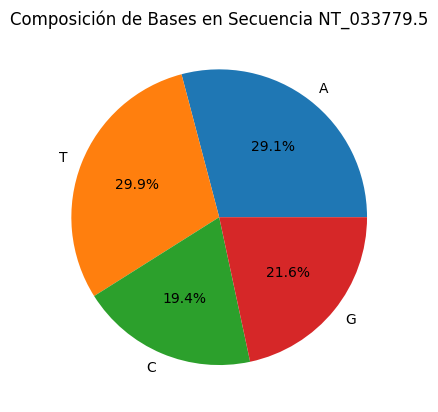

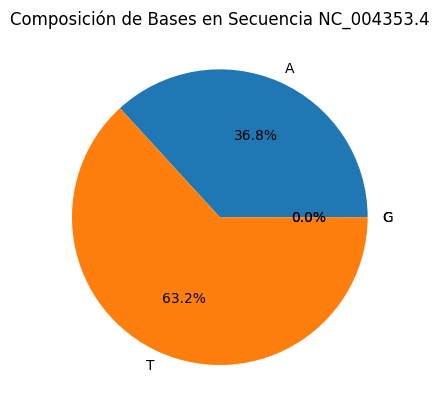

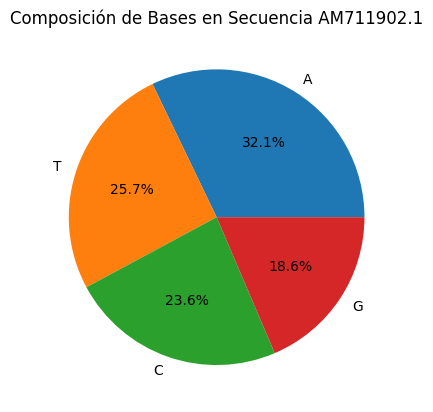

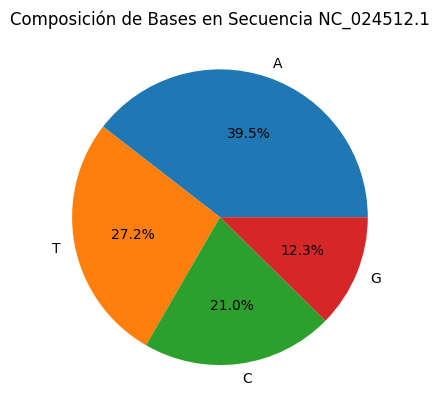

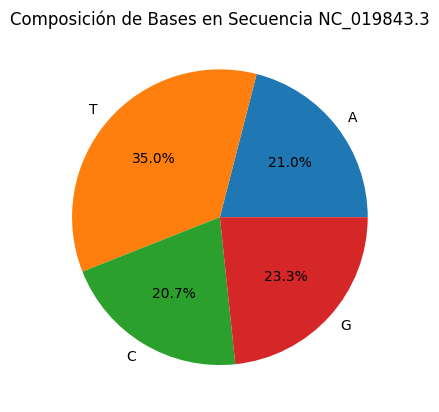

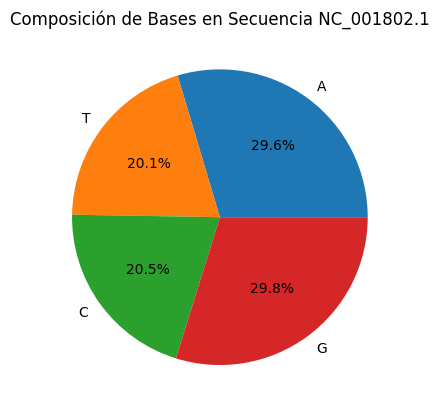

In [ ]:
from Bio import SeqIO
import matplotlib.pyplot as plt

def pie_chart_bases(fasta_file):
  records = SeqIO.parse(fasta_file, "fasta")  # leemos el archivo fasta
  counts = {}                                 # creamos un diccionario vacío donde guardaremos la cuantas bases hay de cada
  for seq_record in records:                  # para cada secuencia contamos las 4 bases y las guardamos en el diccionario
    counts["A"] = seq_record.seq.count("A")
    counts["T"] = seq_record.seq.count("T")
    counts["C"] = seq_record.seq.count("C")
    counts["G"] = seq_record.seq.count("G")
    plt.pie(counts.values(), autopct = '%1.1f%%', labels = list(counts.keys()) )    # representamos los valores del diccionario, con su porcentaje (autopct) y ponemos como etiquetas las claves
    plt.title("Composición de Bases en Secuencia " +  seq_record.id)      # añadimos el título con el id de la secuencia
    plt.show()                                                             # e indicamos que se muestre el gráfico de cada iteración, que se corresponderá a cada secuencia


# Uso de la función
fasta_file = "multipleSeqs.fa"
pie_chart_bases(fasta_file)

## Reversa complementaria con Biopython


In [ ]:
sequencia = "CTACTCACCGGATGAAGTGAGGGTCTCACCCCAACGCGGCCTTAGCTTCCTCGGAAGGACCGAACACCTT"

In [ ]:
from Bio.Seq import Seq
def complementaria(sec):
  seq = Seq(sec)                          # pasamos la secuencia a un objeto Seq de bipython
  rev_comp = seq.reverse_complement()     # así podemos utilizar la función reverse_complement()
  return rev_comp                         # que nos dará la reversa complementaria de la secuencia
print(complementaria(sequencia))

AAGGTGTTCGGTCCTTCCGAGGAAGCTAAGGCCGCGTTGGGGTGAGACCCTCACTTCATCCGGTGAGTAG


Testea que tu código es correcto con el siguiente test unitario


In [ ]:
%%ipytest
# Test Ejercicio 4
def test_compl():
  assert complementaria(sequencia) == "AAGGTGTTCGGTCCTTCCGAGGAAGCTAAGGCCGCGTTGGGGTGAGACCCTCACTTCATCCGGTGAGTAG"


.                                                                                            [100%]
1 passed in 0.01s


## EcoRV - enzimas de restricción
EcoRV es una enzima de restricción muy empleada en todos los laboratorios del mundo para cortar una hebra de ADN en dos partes. EcoRV reconoce el motivo GAT\*ATC, separando la secuencia inicial de ADN por la posición indicada por el '\*'. La siguiente función reconoce ese motivo (GATATC) en una secuencia dada y la separa en dos partes (emplea el símbolo `+`para indicar las dos partes):

EcoRV(GTTGGTGTGCTGCACCTGTTAACTCGTCATTTACATTAAGGATATCTCCTAATGCTATCCCTCCCCCCTC) = GTTGGTGTGCTGCACCTGTTAACTCGTCATTTACATTAAGGAT + ATCTCCTAATGCTATCCCTCCCCCCTC

In [ ]:
seq = 'GTTGGTGTGCTGCACCTGTTAACTCGTCATTTACATTAAGGATATCTCCTAATGCTATCCCTCCCCCCTC'

def ecorv(seq):
  indice = seq.find("GATATC")       # la funcion find nos dará el índice donde se encuentra el motivo, o -1 en caso de que el motivo no este presente
  if indice != -1:                  # si el indice es distinto de -1, es decir, si el motivo está presente en la cadena
    cadena1 = seq[0:(indice+3)]     # la cadena 1 irá desde el inicio hasta tres posiciones mas adelante del inicio del motivo, que es el sitio de corte
    cadena2 = seq[(indice+3):]      # y la cadena 2 desde el inicio del motivo + 3 hasta el final
    cadenas = cadena1 + " + " + cadena2
  return cadenas

Testea que tu código es correcto con el siguiente test unitario


In [ ]:
%%ipytest
# Test Ejercicio 5
def test_ecorv():
  assert ecorv(seq) == "GTTGGTGTGCTGCACCTGTTAACTCGTCATTTACATTAAGGAT + ATCTCCTAATGCTATCCCTCCCCCCTC"


.                                                                                            [100%]
1 passed in 0.01s


## Codones STOP
La siguiente función detecta los codones stop de una secuencia de DNA forward y sus posiciones (en lenguaje python, es decir, comenzando por 0). Para este caso se extraen los codones stop (keys) y sus posiciones (values) en un diccionario. La secuencia es la siguiente: "ATGCGAATAGCTAGCATTGATAAAGCTAAGATTGATA"


In [ ]:
from Bio import SeqUtils
codons_stop = ["TAA", "TAG", "TGA"]

def encontrar_codones_stop(secuencia_adn_codificante):
  stops = {}                                                        # creamos un diccionario vacio
  for stop in codons_stop:                                          # por cada tipo de stop
    s = Bio.SeqUtils.nt_search(secuencia_adn_codificante, stop)     # lo buscaremos en la cadena y añadiremos al diccionario
    stops[stop] = s[1:]                                             # la secuencia stop como clave y sus posiciones como valor
                                                                    # como la función nt_serach nos devuelve una lista con varios elementos, el primero la
  return stops                                                      # subsecuencia que buscamos, y después las posiciones en las que se encuentra, añadimos
                                                                    # como valor al diccionario s[1:] para añadir todas las posiciones sin la subsecuencia
# Secuencia para extraer codones stop y sus posiciones
secuencia_adn_codificante = "ATGCGAATAGCTAGCATTGATAAAGCTAAGATTGATA"

codones_stop = encontrar_codones_stop(secuencia_adn_codificante)


Testea que tu código es correcto con el siguiente test unitario


In [ ]:
%%ipytest
# Test Ejercicio 6
def test_ecorv():
  assert codones_stop['TAA'] == [20, 26]
  assert codones_stop['TAG'] == [7, 11]
  assert codones_stop['TGA'] == [17, 32]

.                                                                                            [100%]
1 passed in 0.01s


## Distancia de Hamming
La distancia de Hamming es una función entre dos secuencias *p* y *q* (en nuestro caso nos limitaremos a secuencias de la misma longitud), que nos indica el número de símbolos que para cada posición *i* en *p* y *q* son diferentes. Por ejemplo, sea p=CCGTA y q=ACGTC. Su distancia de Hamming será 2 (la primera y última posiciones son diferentes).



In [ ]:
p = 'ATTGCCCATAATGTCCCTCAGTAATTCCACTGCACTCGCCACCTTTTTTTTGCAGCTGCTGTGTGCTGGAGCT\
GACCCCTCGGTAATCTCTTGTCTGCTTTTTAGGAACTCCTATCTCCAGATCTTCTTTTACTTCCCAAGCCACC'
q = 'AATGCCCATAATGTCCCTCACTAATTCCACTGCATTTACTTTGCAGCTGCTGTGTGCTGTAGCTGTGAGGAAC\
GCACCCAACTCATCTCTTGTCTGCTTTTTAGGAACCCTATCTCCAGAACTCTTCTTTTACTTAAGGCCTATCC'

def hamming(p, q):
  dist = 0                      # creamos un contador para la distancia
  for i in range(len(p)):       # por cada posición en p y q
    if p[i] != q[i]:            # si la base es distinta
      dist += 1                 # sumamos 1 a la distancia
  return dist


Testea que tu código es correcto con el siguiente test unitario


In [ ]:
%%ipytest
# Test Ejercicio 7
def test_hamming():
  assert hamming(p, q) == 73


.                                                                                            [100%]
1 passed in 0.01s


## Búsqueda de motivos


In [ ]:
def buscar_motivo(t, s):
  posiciones = []                       # creamos unas lista vacía en la que guardaremos las posiciones
  for i in range(len(t)-len(s)+1):      # por cada posición en la cadena t
    if t[i:i+len(s)] == s:              # si la subcadena desde la posición i con el largo de s es igual a s
      posiciones.append(i)              # añadimos su posicion de inicio i a la lisla posiciones
  if posiciones:                        # finalmente, si la lista no está vacía, la devoldemos
    return posiciones
  else:                                 # sino devolveremos [-1]
    return [-1]


t = 'AUGCUUCAGAAAGGUCUAUACGUGCUUUA'
s = 'CUUA'
print(buscar_motivo(t, s))

t = 'AUGCUUCAGTAAGGUCUUACGUUUAGTCGATUUATCGAGTUU'
s = 'CUU'
print(buscar_motivo(t, s))

t = 'AUGCUUCAGTAAGGUCUUACGUUUAGTCGATUUATCGAGTUU'
s = 'T'
print(buscar_motivo(t, s))

t = 'AUGCUUCAGAAAGGUCUUACGU'
s = 'GU'
print(buscar_motivo(t, s))

t = 'GCGTAGTAGGTTCAAAGCCTAGTTCCGCCGAAAGACAAAGGAGAAGGGAATGCTCCT\
AGTAGTTTCAGTCTAGCAAACATGTTATAACGCTAACTGTGTGCTGCA'
s = 'AAG'
print(buscar_motivo(t, s))

t = 'GCGTAGTAGGTTCGCCTAGTTCCGCCGAAAGACAAAGGAGAAGGGAATGCTCCT\
AGTAGTTTCAGTATAGCAAACATGTTATAACGCCTAACTGTGTGCTGCA'
s = 'AGTC'
print(buscar_motivo(t, s))

[-1]
[3, 15]
[9, 26, 30, 34, 39]
[13, 20]
[14, 31, 37, 43]
[-1]


Testea que tu código es correcto con el siguiente test unitario


In [ ]:
%%ipytest
# Test Ejercicio 8
def test_motivo():
  t = 'AUGCUUCAGAAAGGUCUAUACGUGCUUUA'
  s = 'CUUA'
  assert buscar_motivo(t, s) == [-1]

  t = 'AUGCUUCAGTAAGGUCUUACGUUUAGTCGATUUATCGAGTUU'
  s = 'CUU'
  assert buscar_motivo(t, s) == [3, 15]

  t = 'AUGCUUCAGTAAGGUCUUACGUUUAGTCGATUUATCGAGTUU'
  s = 'T'
  assert buscar_motivo(t, s) == [9, 26, 30, 34, 39]

  t = 'AUGCUUCAGAAAGGUCUUACGU'
  s = 'GU'
  assert buscar_motivo(t, s) == [13, 20]

  t = 'GCGTAGTAGGTTCAAAGCCTAGTTCCGCCGAAAGACAAAGGAGAAGGGAATGCTCCT\
  AGTAGTTTCAGTCTAGCAAACATGTTATAACGCTAACTGTGTGCTGCA'
  s = 'AAG'
  assert buscar_motivo(t, s) == [14, 31, 37, 43]

  t = 'GCGTAGTAGGTTCGCCTAGTTCCGCCGAAAGACAAAGGAGAAGGGAATGCTCCT\
  AGTAGTTTCAGTATAGCAAACATGTTATAACGCCTAACTGTGTGCTGCA'
  s = 'AGTC'
  assert buscar_motivo(t, s) == [-1]


.                                                                                            [100%]
1 passed in 0.01s



## Mutaciones puntuales
Código en Python que calcula la relación entre transiciones y transversiones:

In [ ]:
def rel_trans(s1, s2):
  transiciones = 0
  transversiones = 0
  for i in range(len(s1)):                      # para cada base en las secuencias
    if s1[i] != s2[i]:                          # comprobamos si son distintas
      if (s1[i] == 'A') or (s1[i] == 'G'):      # si lo son, en caso de que en la cadena 1 tengamos una A o G
        if (s2[i] == 'A') or (s2[i] == 'G'):    # si en la cadena dos también hay una A o G,
          transiciones += 1                     # añadimos una transición
        if (s2[i] == 'C') or (s2[i] == 'T'):    # si en la cadena 2 hay una C o T,
          transversiones += 1                   # añadimos una transversión
      if (s1[i] == 'T') or (s1[i] == 'C'):      # en caso de que en la cadena 1 tengamos una T o C:
        if (s2[i] == 'T') or (s2[i] == 'C'):    # si en la cadena 2 también hay una T o C
          transiciones += 1                     # Añadimos una transición
        if (s2[i] == 'A') or (s2[i] == 'G'):    # y si en la cadena 2 hay una A o G,
          transversiones += 1                   # añadimos una transversión
  r = transiciones / transversiones             # calculamos la relación entre transición y transversión
  return r

s1 = """TTTTGTCATTTTGCCTCGTCGTCAGGAATATTGGGACGAATTGGACTCTACT
TCTGTGGGCTGAGCCGGTTCACCCATTGACGAGTGCTAGTCACAGATGAATTACAATGAA
CGCTCGAGAAAGTGCTAATAAACGAACAGCACTAACATATGGGGGCGCGGCTGCCGGGCG
ACATGGCCGATTTAAAACACGACTGTAAGGACTGATAAACGTGTAGCATTTTCAAGTCTC
GTCGCGATGTACAAATATCGTGTTCCCTAGCTCAGGGCGCACGCTAAGGACAAACGGTGT
CACCGAATTTTCCAACGGAACACACATCAACGTGCGAGATTTCGTATGTACCCCCAT
TGTATTGAGATGGCATCTGCTCCGAACGTTGAGATCACGCCAGCACTTACAGAACATTCC
TAGTGTGGATCTATTAATAGACGGACTGAAACATTAGGGTGGGAAGTGAGCTATGGCTCA
CACCAAGCATCGGTTTCTTCTTGGACGGTGTCCCCACCATTTGTTATTGTGCTCTAG
AAACACTATAAAGCCTTTAATAAATTCACCGCTGTCGTATCCAAAAGCCGGGTCTGCCTC
CTGATGCGTCTCGCGGCTATGGCTGGGTCACACCCCGACAGTCCAGTACCGTCGGTGCCG
GAGATAGTGTCGCAGGCGTTCTATGGAGATGGACGGCCATCCATACCCAGTCAGCAAAAC
TACCGATCTCTCGGATATCTGTAGGTGGAGCTATTGTCGATAGCTATAAACCAGACTCGG
AGAGTAATATGAAATGGAAGTGAGTGCTGGCGAGGCTTTGTGTACTTGTCTGATTTTGTG
TTGATTTA"""

s2 = """CCTTGTAAGTACGCGTAGCCTCCAGGAACTTTTAGGCGAATTGTACGTCACC
TCCGGGAGCCGGGCCGGTTGATCCTTTGACAAGTCCTCACAGATGTGTCACAACCAACTG
CCCTTGGAAGGGTGCCAGTTAACAAGCGGTAGCAGGACATGAGGACGCGACTGCCGGAAG
ACATGACCAGCTTAAAACACAACTGTCGGGACGGAACGTACTGTATCCTTGAATCTCTTT
GTCGCAGTGTAGAAAAGGCGTTCTCCCTGGTTCAGGGCGCATGCTAGGGATAAACGGTGT
AGTTAAAGATGACGAGGGAAGACGCATCGATGCATGTGACTCCGGATGTACCTCGGT
TATATTGAGAGGGTATCCGCTCGAGACGTTAAAATCCCGTTAGTATTCTCTGGACATTCT
TGACGTGGATCTTTGGCGCGGACTATAGTGGTAGGGCGGGGAGCGACCTATGACTCA
CATCAAGCATCAGCTTTCACTTGGACAGAACTGCGTACACATATCGTTACCGCACTTTGA
AAACATTAGGGAGCTCTTAGTAGATTAGGCGCTGTCGTATCTAAAGGCCAGATCTGTCCT
TTGCTGAATCTCGCGGCCATGTCCGTGTGAAGCCCCGACGACTTAAGGTTAGTGGCGCGA
AAGATAGGGTCGTAGGCGATCGATGGAGATGGATAGCTATGCGTATCCGTTCTGTGGTAT
GCTAAATCTCATAGATAGCTGTGGGTGAAGTTCATATAGACAGCTCTAAGCCACACCCGG
GGAATAATATGGAGTGGGAATGAGAGCTGTCGTGGCTTTGTGCACCTGTCGGATCTCCTA
TTGATCTG"""

print(rel_trans(s1, s2))


1.3428571428571427


Testea que tu código es correcto con el siguiente test unitario


In [ ]:
%%ipytest
import pytest
# Test Ejercicio 9
def test_rel_trans():
  s1 = """TTTTGTCATTTTGCCTCGTCGTCAGGAATATTGGGACGAATTGGACTCTACT
  TCTGTGGGCTGAGCCGGTTCACCCATTGACGAGTGCTAGTCACAGATGAATTACAATGAA
  CGCTCGAGAAAGTGCTAATAAACGAACAGCACTAACATATGGGGGCGCGGCTGCCGGGCG
  ACATGGCCGATTTAAAACACGACTGTAAGGACTGATAAACGTGTAGCATTTTCAAGTCTC
  GTCGCGATGTACAAATATCGTGTTCCCTAGCTCAGGGCGCACGCTAAGGACAAACGGTGT
  CACCGAATTTTCCAACGGAACACACATCAACGTGCGAGATTTCGTATGTACCCCCAT
  TGTATTGAGATGGCATCTGCTCCGAACGTTGAGATCACGCCAGCACTTACAGAACATTCC
  TAGTGTGGATCTATTAATAGACGGACTGAAACATTAGGGTGGGAAGTGAGCTATGGCTCA
  CACCAAGCATCGGTTTCTTCTTGGACGGTGTCCCCACCATTTGTTATTGTGCTCTAG
  AAACACTATAAAGCCTTTAATAAATTCACCGCTGTCGTATCCAAAAGCCGGGTCTGCCTC
  CTGATGCGTCTCGCGGCTATGGCTGGGTCACACCCCGACAGTCCAGTACCGTCGGTGCCG
  GAGATAGTGTCGCAGGCGTTCTATGGAGATGGACGGCCATCCATACCCAGTCAGCAAAAC
  TACCGATCTCTCGGATATCTGTAGGTGGAGCTATTGTCGATAGCTATAAACCAGACTCGG
  AGAGTAATATGAAATGGAAGTGAGTGCTGGCGAGGCTTTGTGTACTTGTCTGATTTTGTG
  TTGATTTA"""

  s2 = """CCTTGTAAGTACGCGTAGCCTCCAGGAACTTTTAGGCGAATTGTACGTCACC
  TCCGGGAGCCGGGCCGGTTGATCCTTTGACAAGTCCTCACAGATGTGTCACAACCAACTG
  CCCTTGGAAGGGTGCCAGTTAACAAGCGGTAGCAGGACATGAGGACGCGACTGCCGGAAG
  ACATGACCAGCTTAAAACACAACTGTCGGGACGGAACGTACTGTATCCTTGAATCTCTTT
  GTCGCAGTGTAGAAAAGGCGTTCTCCCTGGTTCAGGGCGCATGCTAGGGATAAACGGTGT
  AGTTAAAGATGACGAGGGAAGACGCATCGATGCATGTGACTCCGGATGTACCTCGGT
  TATATTGAGAGGGTATCCGCTCGAGACGTTAAAATCCCGTTAGTATTCTCTGGACATTCT
  TGACGTGGATCTTTGGCGCGGACTATAGTGGTAGGGCGGGGAGCGACCTATGACTCA
  CATCAAGCATCAGCTTTCACTTGGACAGAACTGCGTACACATATCGTTACCGCACTTTGA
  AAACATTAGGGAGCTCTTAGTAGATTAGGCGCTGTCGTATCTAAAGGCCAGATCTGTCCT
  TTGCTGAATCTCGCGGCCATGTCCGTGTGAAGCCCCGACGACTTAAGGTTAGTGGCGCGA
  AAGATAGGGTCGTAGGCGATCGATGGAGATGGATAGCTATGCGTATCCGTTCTGTGGTAT
  GCTAAATCTCATAGATAGCTGTGGGTGAAGTTCATATAGACAGCTCTAAGCCACACCCGG
  GGAATAATATGGAGTGGGAATGAGAGCTGTCGTGGCTTTGTGCACCTGTCGGATCTCCTA
  TTGATCTG"""
  assert rel_trans(s1, s2) == pytest.approx(1.3309859154929577)

F                                                                                            [100%]
============================================= FAILURES =============================================
__________________________________________ test_rel_trans __________________________________________

    def test_rel_trans():
      s1 = """TTTTGTCATTTTGCCTCGTCGTCAGGAATATTGGGACGAATTGGACTCTACT
      TCTGTGGGCTGAGCCGGTTCACCCATTGACGAGTGCTAGTCACAGATGAATTACAATGAA
      CGCTCGAGAAAGTGCTAATAAACGAACAGCACTAACATATGGGGGCGCGGCTGCCGGGCG
      ACATGGCCGATTTAAAACACGACTGTAAGGACTGATAAACGTGTAGCATTTTCAAGTCTC
      GTCGCGATGTACAAATATCGTGTTCCCTAGCTCAGGGCGCACGCTAAGGACAAACGGTGT
      CACCGAATTTTCCAACGGAACACACATCAACGTGCGAGATTTCGTATGTACCCCCAT
      TGTATTGAGATGGCATCTGCTCCGAACGTTGAGATCACGCCAGCACTTACAGAACATTCC
      TAGTGTGGATCTATTAATAGACGGACTGAAACATTAGGGTGGGAAGTGAGCTATGGCTCA
      CACCAAGCATCGGTTTCTTCTTGGACGGTGTCCCCACCATTTGTTATTGTGCTCTAG
      AAACACTATAAAGCCTTTAATAAATTCACCGCTGTCGTATCCAAAAGCCGGGTCTGCCTC
      C

## Filogenia

Diseño de árbol filogenético

Tree(rooted=False, weight=1.0)
    Clade()
        Clade()
            Clade(name='A')
                Clade()
                    Clade(name='B')
                    Clade(name='C')
                Clade()
                    Clade(name='D')
                    Clade(name='E')
        Clade(name='K')
            Clade(name='F')
            Clade(name='G')
        Clade()
            Clade(name='H')
                Clade(name='I')
                Clade(name='J')
                Clade(name='L')


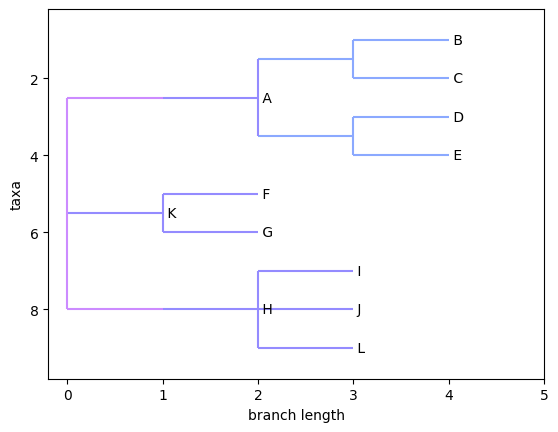

In [ ]:
%matplotlib inline

from Bio import Phylo

tree = Phylo.read("arbol.dnd", "newick")   # importamos el árbol del archivo que hemos creado
# representacion del arbol
print(tree)

# imagen del árbol
# para dar color a las diferentes ramas, utilizamos las funciones root.color, todo el árbol desde la raíz
tree.root.color = "#cc8bff"

# para dar colores espicificos a clados podemos utilizar common_antecesor, con lo que daremos color a todas las ramas
# que surjan del ancestro común de los individuos dados, por ello cuando coloreamos desde el ancestro común de I y J,
# aparece del mismo color la rama de L, ya que tiene el mismo ancestro común que los otros dos.
mrcaA = tree.common_ancestor({"name": "E"}, {"name": "B"})
mrcaA.color = "#948bff"
mrcaB = tree.common_ancestor({"name": "F"}, {"name": "G"})
mrcaB.color = "#948bff"
mrcaC = tree.common_ancestor({"name": "I"}, {"name": "J"})
mrcaC.color = "#948bff"
mrcaD = tree.common_ancestor({"name": "B"}, {"name": "C"})
mrcaD.color = "#8ba9ff"
mrcaE = tree.common_ancestor({"name": "D"}, {"name": "E"})
mrcaE.color =  "#8ba9ff"
Phylo.draw(tree)


## Alineamiento de secuencias
Tenemos dos secuencias de ADN, y queremos realizar un alineamiento para identificar regiones de homología. En el siguiente ejercicio, utilizamos Biopython para realizar un alineamiento de secuencias de ADN y visualizar el resultado con un gráfico en matriz.


In [ ]:
# Secuencias de ADN

from Bio import Seq

secuencia1 = Seq.Seq("ATCGATCG")
secuencia2 = Seq.Seq("ATAGATCG")

from Bio import Align
# Comenzamos creando una función de alineamiento que nos alinee las secuencias dadas
aligner = Align.PairwiseAligner(match_score=1.0)
alignments = aligner.align(secuencia1,secuencia2)
# visualizamos los alineamientos
for alignment in alignments:
  print(alignment)


target            0 ATC-GATCG 8
                  0 ||--||||| 9
query             0 AT-AGATCG 8

target            0 AT-CGATCG 8
                  0 ||--||||| 9
query             0 ATA-GATCG 8

target            0 ATCGATCG 8
                  0 ||.||||| 8
query             0 ATAGATCG 8



In [ ]:
import numpy as np
# nos quedamos con el primer alineamiento de los tres resultantes
alignment = alignments[0]
sec1 , sec2 = alignment[0] , alignment[1]     # guardamos cada secuencia en un objeto

# creamos una matriz en la que las filas serán las bases de la secuencia 1
# y las columnas los elementos de la secuencia 2, cada missmatch será un 0 y
# cada match un 1:

mat = np.zeros((len(sec1),len(sec2)))
for i in range(len(sec1)):
  for j in range(len(sec2)):
    if sec1[i] == sec2[j]:
      mat[i,j] = 1
mat

array([[1., 0., 0., 1., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 1.]])

Text(0.5, 1.0, 'Alineamiento de Homología')

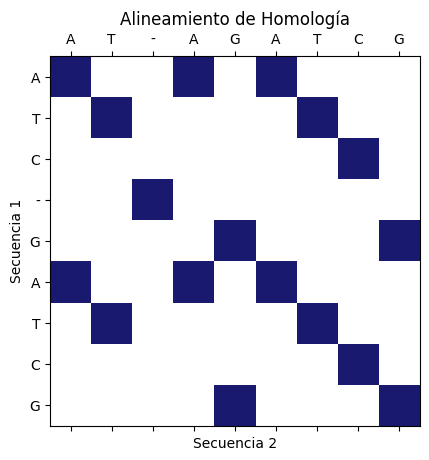

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# representamos la matriz de 0 y 1 obtenida del apartado anterior

fig = plt.figure()
ax = fig.add_subplot(111)
cmap = ListedColormap(['w', 'midnightblue'])        # creamos nuestro mapa de colores tal que 0 = blanco, 1 = azul
ax.matshow(mat, cmap = cmap)
xaxis = np.arange(len(sec1))
# añadimos las bases de las secuencias como etiquetas de los ejes
ax.set_xticks(xaxis)
ax.set_yticks(xaxis)
ax.set_xticklabels(sec2)
ax.set_yticklabels(sec1)
# y añadimos los títulos de los ejes y el gráfico
ax.set_xlabel("Secuencia 2")
ax.set_ylabel("Secuencia 1")
ax.set_title("Alineamiento de Homología")